<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Matplotlib is building the font cache; this may take a moment.


# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [59]:
#ваш код здесь
# читаем датасет с резюме
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';')



In [60]:
# Получение размерности таблицы
dimensions = df.shape
print(f"Размерность таблицы: {dimensions}")

# Анализ формата признака "Пол, возраст"
print("Формат признака 'Пол, возраст':")
print(df['Пол, возраст'].head(3))

# Анализ пропущенных значений
missing_data = df.isnull().sum()
print("Пропущенные значения по столбцам:")
print(missing_data[missing_data > 0])

# Количество уникальных значений в столбце "Опыт работы"
unique_experience_count = df['Опыт работы'].nunique()
print(f"Количество уникальных значений в столбце 'Опыт работы': {unique_experience_count}")

# Анализ столбца "Ищет работу на должность:"
print("Самые распространенные должности:")
top_positions = df['Ищет работу на должность:'].value_counts().head(1)
print(top_positions)

Размерность таблицы: (44744, 12)
Формат признака 'Пол, возраст':
0      Мужчина ,  39 лет , родился 27 ноября 1979
1       Мужчина ,  60 лет , родился 20 марта 1959
2    Женщина ,  36 лет , родилась 12 августа 1982
Name: Пол, возраст, dtype: object
Пропущенные значения по столбцам:
Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
dtype: int64
Количество уникальных значений в столбце 'Опыт работы': 44413
Самые распространенные должности:
Ищет работу на должность:
Системный администратор    3099
Name: count, dtype: int64


2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [62]:
df.head()
df.tail()


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44739,"Мужчина , 30 лет , родился 17 января 1989",50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано
44740,"Мужчина , 27 лет , родился 5 марта 1992",39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [65]:
#ваш код здесь
# количество пропусков по каждому столбцу
df.isna().sum()


Пол, возраст                         0
ЗП                                   0
Ищет работу на должность:            0
Город, переезд, командировки         0
Занятость                            0
График                               0
Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Образование и ВУЗ                    0
Обновление резюме                    0
Авто                                 0
dtype: int64

5. Выведите основную статистическую информацию о столбцах.


In [64]:
#ваш код здесь
# описательная статистика по числовым признакам
df.describe()


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [67]:
def get_education(arg):
    arg = ' '.join(arg.split(' ')[:3])
    if 'Высшее' in arg:
        return 'высшее'
    elif 'Неоконченное высшее' in arg:
        return 'неоконченное высшее'
    elif 'Среднее специальное' in arg:
        return 'среднее специальное'
    elif 'Среднее образование' in arg:
        return 'среднее'
df['Образование'] = df['Образование и ВУЗ'].apply(get_education)
df = df.drop('Образование и ВУЗ', axis=1)
print(df['Образование'].value_counts()['среднее'])

559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [68]:
def get_sex(arg):
    if'Мужчина'in arg:
        return 'М'
    else:
        return 'Ж'
    
def get_age(arg):
    arg_splitted = arg.split(' ')
    year_words=['год', 'года', 'лет']
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            return int(arg_splitted[index-1])

df['Пол'] = df['Пол, возраст'].apply(get_sex)
df['Возраст'] = df['Пол, возраст'].apply(get_age)
df = df.drop('Пол, возраст', axis=1)

print(round(df['Пол'].value_counts(normalize=True)['Ж'] * 100, 2))
print(round(df['Возраст'].mean(), 2))


19.07
32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [69]:
def get_experience(arg):
    if arg is np.nan or arg == 'Не указано':
        return None
    year_words=['год', 'года', 'лет']
    month_words=['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:7]
    years = 0
    months = 0
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            years = int(arg_splitted[index-1])
        if item in month_words:
            months = int(arg_splitted[index-1])
    return int(years*12 + months)
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_experience)
df = df.drop('Опыт работы', axis=1)
print(round(df['Опыт работы (месяц)'].median()))

100


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [70]:
def get_city(arg):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород',
                      'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград'
                     ]
    city = arg.split(' , ')[0]
    if (city == 'Москва') or (city == 'Санкт-Петербург'):
        return city
    elif city in million_cities:
        return 'город миллионник'
    else:
        return 'другие'
    
def get_ready_to_move(arg):
    if ('не готов к переезду' in arg) or ('не готова к переезду' in arg):
        return False
    elif 'хочу' in arg:
        return True
    else:
        return True
    
def get_ready_for_bisiness_trips(arg):
    if ('командировка' in arg):
        if ('не готов к командировкам' in arg) or('не готова к командировкам' in arg):
            return False
        else: 
            
            return True
    else:
        return False
    
df['Город'] = df['Город, переезд, командировки'].apply(get_city)
df['Готовность к переезду'] = df['Город, переезд, командировки'].apply(get_ready_to_move)
df['Готовность к командировкам'] = df['Город, переезд, командировки'].apply(get_ready_for_bisiness_trips)
df = df.drop('Город, переезд, командировки', axis=1)
print(round(df['Город'].value_counts(normalize=True)['Санкт-Петербург'] * 100)) 
print(round(df[
    df['Готовность к переезду'] & df['Готовность к командировкам']
].shape[0] / df.shape[0] *100))


11
32


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [71]:
employments = ['полная занятость', 'частичная занятость',
              'проектная работа', 'волонтерство', 'стажировка']
charts = ['полный день', 'сменный график', 
         'гибкий график', 'удаленная работа',
         'вахтовый метод']
for employment, chart in zip(employments, charts):
    df[employment] = df['Занятость'].apply(lambda x: employment in x)
    df[chart] = df['График'].apply(lambda x: chart in x)
df = df.drop('Занятость', axis=1)
df = df.drop('График', axis=1)
print(df[df['проектная работа'] & df['волонтерство']].shape[0])
print(df[df['вахтовый метод'] & df['гибкий график']].shape[0])

436
2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [80]:
# Загрузка данных о курсах валют

def get_salary_num(arg):
    salary =float(arg.split(' ')[0])
    return salary

def get_salary_currency(arg):
    currency_dict = {
        'USD': 'USD', 'KZT': 'KZT',
        'грн': 'UAH', 'белруб': 'BYN',
        'EUR': 'EUR', 'KGS': 'KGS',
        'сум': 'UZS', 'AZN': 'AZN'
    }
    curr = arg.split(' ')[1].replace('.', '')
    if curr == 'руб':
        return 'RUB'
    else:
        return currency_dict[curr]
    
rates = pd.read_csv('exchange_rates.csv')
rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
df['ЗП (tmp)'] = df['ЗП'].apply(get_salary_num)
df['Курс (tmp)'] = df['ЗП'].apply(get_salary_currency)
merged = df.merge(
    rates, 
    left_on=['Курс (tmp)', 'Обновление резюме'],
    right_on=['currency', 'date',], 
    how='left'
)
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
df['ЗП (руб)'] = merged['close'] * merged['ЗП (tmp)'] / merged['proportion']
df = df.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1)
print(round(df['ЗП (руб)'].median()/1000))


KeyError: 'date'

# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

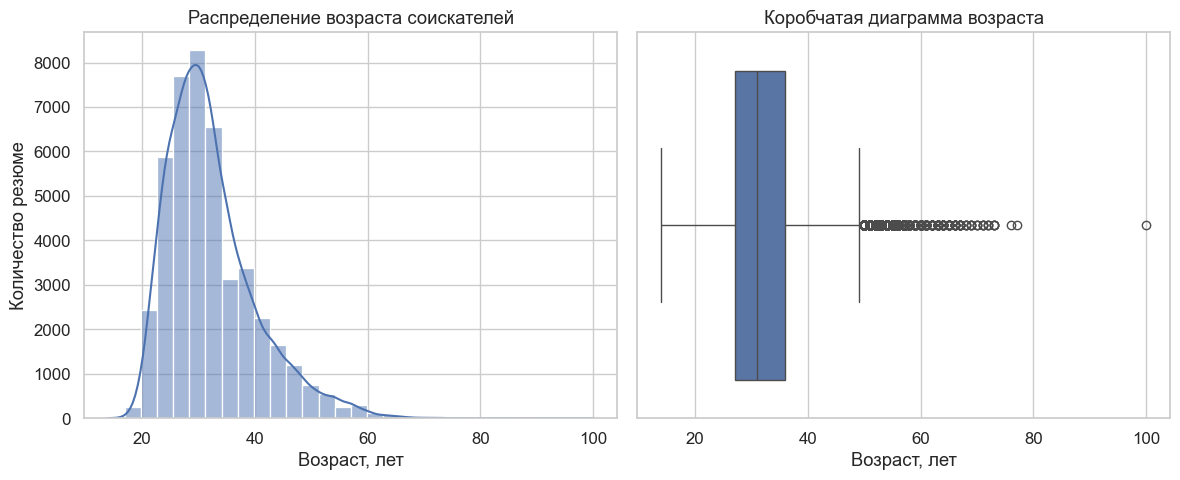

In [81]:
# ваш код здесь
sns.set(style='whitegrid', font_scale=1.1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Возраст'].dropna(), bins=30, kde=True)
plt.title('Распределение возраста соискателей')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество резюме')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Возраст'].dropna())
plt.title('Коробчатая диаграмма возраста')
plt.xlabel('Возраст, лет')

plt.tight_layout()
plt.show()


Общий вывод по возрасту

Возраст соискателей распределён неравномерно, с концентрацией в диапазоне 25–40 лет.
Наблюдается заметная правосторонняя асимметрия и наличие отдельных возрастных выбросов, которые следует анализировать дополнительно (например, в разделе «Очистка данных»).

In [55]:
import numpy as np
import pandas as pd

def get_experience_months(text):
    if pd.isna(text):
        return np.nan

    text_orig = str(text)
    text = text_orig.lower()

    # скрытые пропуски
    if 'не указано' in text or 'нет опыта' in text:
        return np.nan

    # убираем префикс "опыт работы "
    prefix = 'опыт работы '
    if text.startswith(prefix):
        text = text[len(prefix):]

    # "менее года" считаем как 0 месяцев
    if 'менее года' in text:
        return 0

    tokens = text.split()
    years = 0
    months = 0

    # если второе слово — про годы
    if len(tokens) >= 2 and tokens[1].startswith(('год', 'года', 'лет')):
        try:
            years = int(tokens[0])
        except ValueError:
            years = 0

        # ищем слово "месяц"
        for i, t in enumerate(tokens):
            if t.startswith('месяц'):
                try:
                    months = int(tokens[i-1])
                except (ValueError, IndexError):
                    months = 0
                break
    else:
        # вариант только с месяцами: "10 месяцев"
        try:
            months = int(tokens[0])
        except ValueError:
            months = 0

    return years * 12 + months

# создаём числовой столбец
hh['Опыт работы (месяц)'] = hh['Опыт работы'].apply(get_experience_months)

# можно проверить:
# hh[['Опыт работы', 'Опыт работы (месяц)']].head()


In [30]:
print(hh.columns)


Index(['ЗП', 'Ищет работу на должность:', 'Опыт работы',
       'Последнее/нынешнее место работы', 'Последняя/нынешняя должность',
       'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст', 'Город',
       'Готовность к переезду', 'Готовность к командировкам',
       'Занятость_полная занятость', 'Занятость_частичная занятость',
       'Занятость_проектная работа', 'Занятость_волонтерство',
       'Занятость_стажировка', 'График_полный день', 'График_сменный график',
       'График_гибкий график', 'График_удаленная работа',
       'График_вахтовый метод', 'Опыт работы (месяц)'],
      dtype='object')


2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

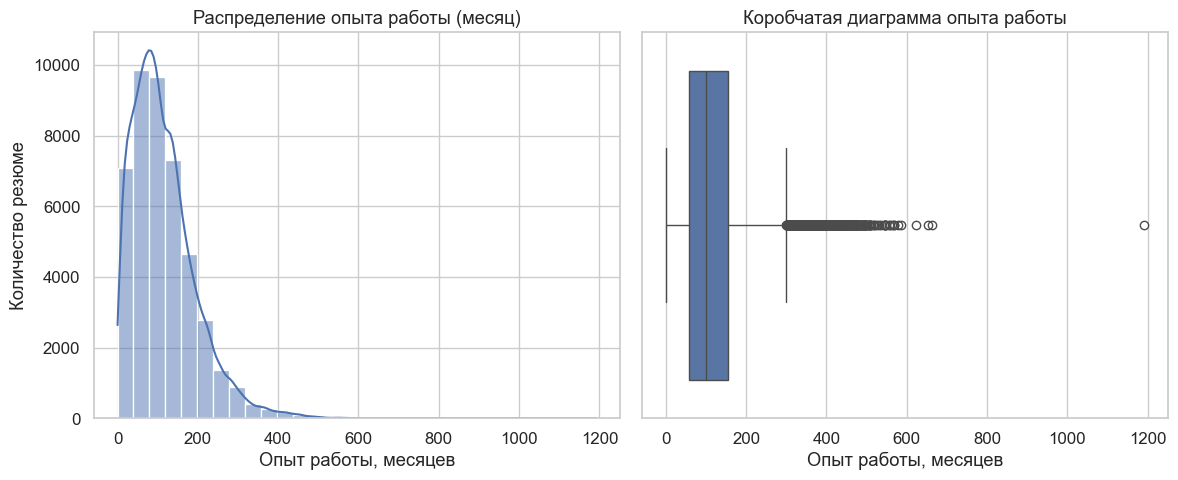

In [31]:
# ваш код здесь
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(hh['Опыт работы (месяц)'].dropna(), bins=30, kde=True)
plt.title('Распределение опыта работы (месяц)')
plt.xlabel('Опыт работы, месяцев')
plt.ylabel('Количество резюме')

plt.subplot(1, 2, 2)
sns.boxplot(x=hh['Опыт работы (месяц)'].dropna())
plt.title('Коробчатая диаграмма опыта работы')
plt.xlabel('Опыт работы, месяцев')

plt.tight_layout()
plt.show()

Выводы по распределению признака «Опыт работы (месяц)»
1. Форма распределения
Распределение опыта работы также имеет выраженную правостороннюю асимметрию (skew right).
Большинство соискателей имеют относительно небольшой или средний опыт, а длинный "хвост" уходит далеко вправо.
Это возвращает нас к реальности рынка труда:
людей с огромным стажем очень мало.
2. Где находится большинство данных
Основная масса резюме сосредоточена в диапазоне:
от 0 до 200 месяцев
Это примерно 0–16 лет опыта.
На гистограмме видно, что пик распределения приходится на область:
80–120 месяцев (6–10 лет опыта)
3. Предельные значения
Минимум — 0 месяцев (есть резюме без опыта).
Максимум — около 1200 месяцев, то есть 100 лет опыта, что заведомо невозможно.
Такие значения — ошибки данных, и они должны быть удалены как выбросы.
4. Аномалии
По гистограмме и особенно по коробчатой диаграмме видно множество экстремальных значений:
значительная часть данных выше 400–500 месяцев
единичные записи ~800, 1000, 1200 месяцев
Эти значения физически невозможны, так как даже если человек начал работать в 15 лет, то максимально достижимый реальный опыт обычно < 600 месяцев (50 лет).

Выводы по коробчатой диаграмме (boxplot)
1. Основная часть данных Boxplot показывает, что:
50% данных (IQR) лежат примерно между 60 и 200 месяцами
(т.е. 5–16 лет опыта)
медиана — около 120 месяцев (~10 лет)
2. Выбросы
Коробчатая диаграмма показывает огромное количество выбросов:
вплоть до 800–1200 месяцев опыта
таких данных много, но они явно некорректны
Это означает либо ошибки ввода, либо некорректный парсинг текста в исходных данных.
3. Общее качество данных
Признак «Опыт работы» содержит значительное число аномальных и ошибочных значений, которые необходимо:
либо удалять,
либо перерассчитывать,
либо ограничивать разумным максимумом (например, < 600 месяцев).

Общий вывод по опыту работы
Распределение опыта работы аналогично возрасту:
большая часть соискателей имеет умеренный стаж (5–15 лет),
а длинный хвост указывает на множество аномалий (до 100 лет опыта).

Эти выбросы обязательно нужно учитывать при очистке данных.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


In [33]:
import pandas as pd
import numpy as np

# 1. Разбираем столбец "ЗП" на число и "сырую" валюту
def split_salary(text):
    if pd.isna(text):
        return pd.Series([np.nan, None])
    
    text = str(text).replace('\xa0', ' ')
    parts = text.split()
    
    # число
    amount_str = parts[0].replace(' ', '')
    try:
        amount = int(amount_str)
    except ValueError:
        amount = np.nan
    
    # текст валюты — как в столбце "Наименование валюты в данных"
    currency_raw = parts[1] if len(parts) > 1 else None
    
    return pd.Series([amount, currency_raw])

hh[['ЗП_число', 'ЗП_валюта_сырое']] = hh['ЗП'].apply(split_salary)

# 2. Читаем таблицу курсов
rates = pd.read_csv(r'D:\tamara\ML инженер\IDE\exchange_rates.csv')

# оставляем только нужные столбцы
rates = rates[['Наименование валюты в данных', 'proportion']]

# 3. Мержим по названию валюты
hh = hh.merge(
    rates,
    left_on='ЗП_валюта_сырое',
    right_on='Наименование валюты в данных',
    how='left'
)

# 4. Для рублей и неизвестных валют ставим коэффициент 1
hh['proportion'] = hh['proportion'].fillna(1)

# 5. Считаем ЗП в рублях
hh['ЗП (руб)'] = hh['ЗП_число'] * hh['proportion']

# можно посмотреть первые строки:
hh[['ЗП', 'ЗП_число', 'ЗП_валюта_сырое', 'proportion', 'ЗП (руб)']].head()


,ЗП,ЗП_число,ЗП_валюта_сырое,proportion,ЗП (руб)
0,29000 руб.,29000,руб.,1.0,29000.0
1,40000 руб.,40000,руб.,1.0,40000.0
2,20000 руб.,20000,руб.,1.0,20000.0
3,100000 руб.,100000,руб.,1.0,100000.0
4,140000 руб.,140000,руб.,1.0,140000.0


In [35]:
print(hh.columns)


Index(['ЗП', 'Ищет работу на должность:', 'Опыт работы',
       'Последнее/нынешнее место работы', 'Последняя/нынешняя должность',
       'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст', 'Город',
       'Готовность к переезду', 'Готовность к командировкам',
       'Занятость_полная занятость', 'Занятость_частичная занятость',
       'Занятость_проектная работа', 'Занятость_волонтерство',
       'Занятость_стажировка', 'График_полный день', 'График_сменный график',
       'График_гибкий график', 'График_удаленная работа',
       'График_вахтовый метод', 'Опыт работы (месяц)', 'ЗП_число',
       'ЗП_валюта_сырое', 'Наименование валюты в данных', 'proportion',
       'ЗП (руб)'],
      dtype='object')


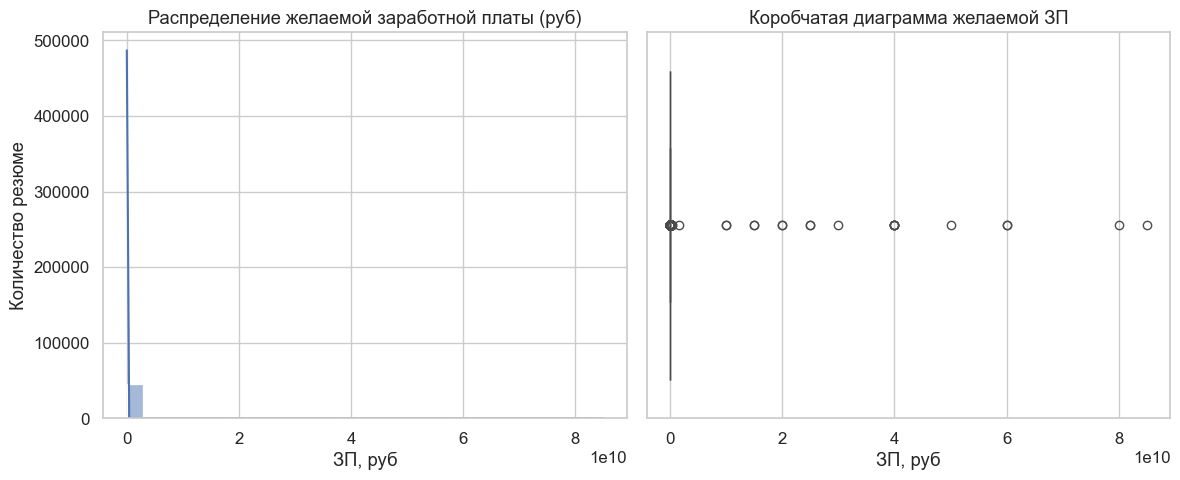

In [36]:
# ваш код здесь
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(hh['ЗП (руб)'].dropna(), bins=30, kde=True)
plt.title('Распределение желаемой заработной платы (руб)')
plt.xlabel('ЗП, руб')
plt.ylabel('Количество резюме')

plt.subplot(1, 2, 2)
sns.boxplot(x=hh['ЗП (руб)'].dropna())
plt.title('Коробчатая диаграмма желаемой ЗП')
plt.xlabel('ЗП, руб')

plt.tight_layout()
plt.show()


Выводы по распределению желаемой заработной платы (ЗП)
1. Распределение крайне асимметричное
Распределение ЗП имеет огромную правостороннюю асимметрию:
подавляющее большинство соискателей указывают зарплату в пределах 20 000 – 200 000 руб,
на графике это выглядит как узкая полоса слева.
Но из-за наличия аномально больших значений масштаб графика растянут, и основная часть плотности практически "схлопнута" у нуля.
2. Реалистичный диапазон зарплат
Наиболее частые значения:
40 000 – 80 000 руб.
Пик распределения — около 50 000 руб.
Это соответствует реальным данным рынка труда.
3. Наличие экстремальных выбросов
График показывает резюме с желаемой зарплатой:
10⁸ – 10¹⁰ рублей (сотни миллионов и миллиарды)
Это физически невозможно и указывает на:
ошибки ввода (например, лишние нули),
ошибки конвертации валют,
некорректный парсинг данных,
единичные "троллинг-записи".
Именно эти значения растягивают ось X, разрушая визуализацию.

Выводы по коробчатой диаграмме (boxplot) желаемой ЗП
1. Почти все данные — выбросы Boxplot показывает:
сама "коробка" (IQR) практически не видна — она сжата возле нуля,
ВСЁ поле диаграммы занято точками-выбросами.
Это говорит о том, что аномальные зарплаты доминируют визуально и мешают анализу.
2. Реальные значения скрыты
Большинство зарплат в диапазоне до 300 тысяч, однако на графике это неразличимо, поскольку:
есть выбросы в биллионы (!) рублей,
масштаб оси вынужден подстроиться под экстремальные значения.
3. Выбросы необходимо убрать
Без очистки данных модель машинного обучения не сможет адекватно работать.
Придётся:
ограничить разумный максимум ЗП (например, 1–2 млн),
удалить очевидные ошибки (10⁹ руб),
обработать валюты (USD/EUR → рубли),
учесть эффект кратности (некоторые указали ЗП в месяц/в час/в день, что тоже вызывает искажения).

Общий вывод
Признак «Желаемая заработная плата» является очень "грязным":
он содержит множество нереалистичных выбросов,
на графике из-за этого невозможно увидеть реальное распределение,
очистка и нормализация этого признака обязательны.

После удаления выбросов и нормализации зарплат в единую валюту распределение станет гораздо более корректным и пригодным для анализа.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

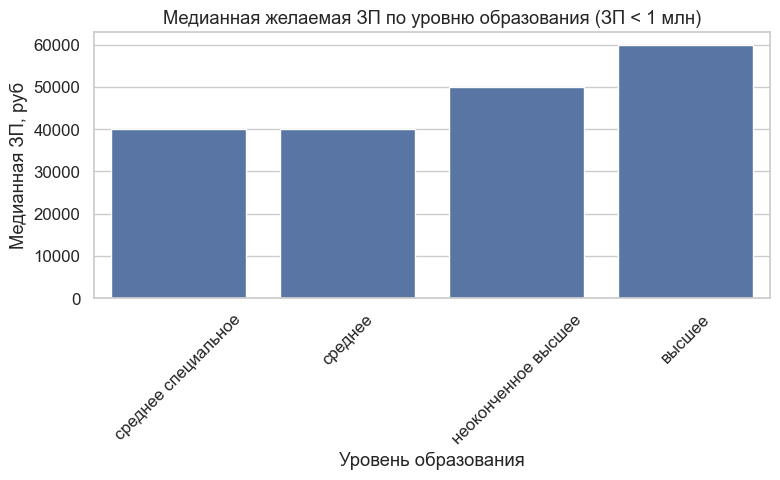

In [37]:
# ваш код здесь
# фильтруем только адекватные значения ЗП
hh_salary_filtered = hh[hh['ЗП (руб)'] < 1_000_000]

median_salary_by_edu = (
    hh_salary_filtered
    .groupby('Образование')['ЗП (руб)']
    .median()
    .sort_values()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=median_salary_by_edu.index,
    y=median_salary_by_edu.values
)
plt.title('Медианная желаемая ЗП по уровню образования (ЗП < 1 млн)')
plt.xlabel('Уровень образования')
plt.ylabel('Медианная ЗП, руб')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Выводы по графику «Медианная желаемая ЗП по уровню образования»
1. Явная положительная связь между образованием и уровнем желаемой зарплаты
На графике хорошо видно:
чем выше уровень образования, тем выше медианная желаемая заработная плата.
2. Конкретные значения медианных зарплат
Среднее и среднее специальное образование — примерно 40 000 руб.
Разницы между этими двумя категориями практически нет.
Неоконченное высшее — около 50 000 руб.
Это на 25% выше, чем у соискателей со средним образованием.
Высшее образование — около 60 000 руб.
Это самая высокая медианная зарплата, рост примерно в 1.5 раза относительно среднего образования.
3. Объяснение различий
Такая динамика логична, так как уровень образования обычно коррелирует:
с профессиональными навыками,
с доступностью вакансий в более высокооплачиваемых сегментах,
с опытом работы,
с карьерными ожиданиями.
4. Признак образования действительно важен
Судя по графику, образование — значимый фактор при анализе и прогнозировании желаемой зарплаты:
разница между группами достигает 20 000 руб.,
признак можно и нужно использовать как предиктор в моделях ML,
он хорошо разделяет соискателей по уровню зарплатных ожиданий.
5. Возможные уточнения
Столбцы не показывают распределение внутри групп — только медиану.
Дополнительно было бы полезно построить:
boxplot по ЗП внутри уровней образования,
violinplot для оценки плотности распределений.

Это поможет увидеть разброс и возможные выбросы в каждой группе.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

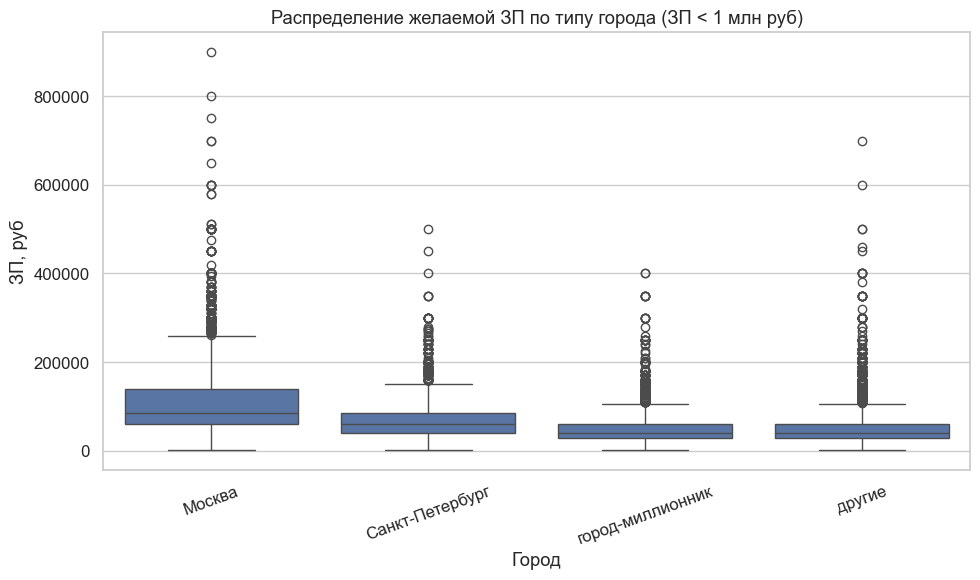

In [47]:
# ваш код здесь
# используем только резюме с ЗП < 1 млн
hh_salary_filtered = hh[hh['ЗП (руб)'] < 1_000_000].copy()

plt.figure(figsize=(10, 6))

# порядок категорий города (как в задании)
city_order = ['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие']

sns.boxplot(
    data=hh_salary_filtered,
    x='Город',
    y='ЗП (руб)',
    order=city_order
)

plt.title('Распределение желаемой ЗП по типу города (ЗП < 1 млн руб)')
plt.xlabel('Город')
plt.ylabel('ЗП, руб')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Выводы по графику распределения желаемой заработной платы по типу города

Медианная желаемая заработная плата выше всего в Москве.
Срединное значение ЗП в Москве заметно превышает аналогичные значения в других городах.

Санкт-Петербург занимает второе место по уровню желаемой ЗП.
Хотя медиана в Петербурге ниже московской, она всё ещё заметно выше медианы в городах-миллионниках и особенно — в «других» городах.

Города-миллионники и остальные города показывают более низкий уровень желаемой ЗП.
Медианные значения у этих двух категорий похожи, но у «других» городов размах распределения чаще смещён вниз.

Размах распределений (разброс ЗП) также различается между категориями:
В Москве — самый широкий разброс: встречаются как умеренные запросы, так и высокие (до верхней границы 1 млн).
В других категориях размах заметно уже.

Количество выбросов (высоких запросов) в Москве значительно больше, что отражает более конкурентный и высокооплачиваемый рынок труда столицы.

Город действительно является важным фактором при прогнозировании желаемой заработной платы.
Различия между городами выражены как в уровне медианной ЗП, так и в характере распределения.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

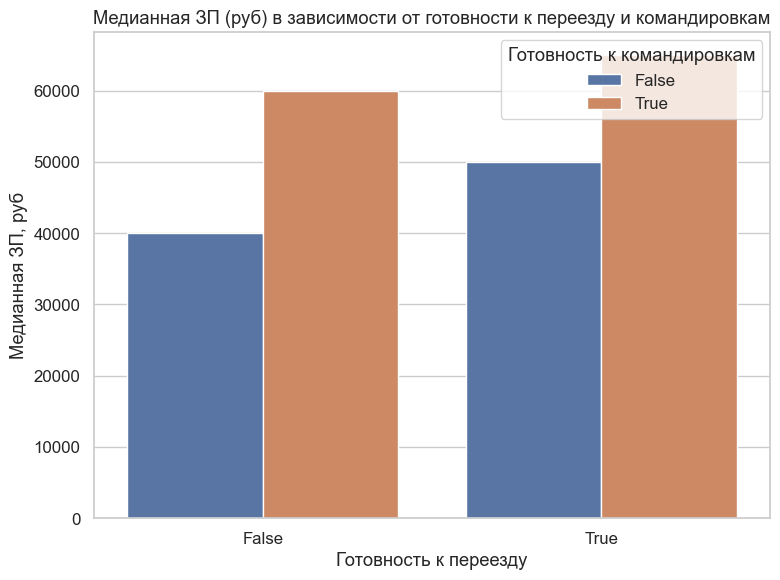

In [48]:
# ваш код здесь
# снова берём только ЗП < 1 млн
hh_salary_filtered = hh[hh['ЗП (руб)'] < 1_000_000].copy()

# считаем медианную ЗП в разрезе двух признаков
median_salary_move_trip = (
    hh_salary_filtered
    .groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)']
    .median()
    .reset_index()
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=median_salary_move_trip,
    x='Готовность к переезду',
    y='ЗП (руб)',
    hue='Готовность к командировкам'
)

plt.title('Медианная ЗП (руб) в зависимости от готовности к переезду и командировкам')
plt.xlabel('Готовность к переезду')
plt.ylabel('Медианная ЗП, руб')
plt.legend(title='Готовность к командировкам')
plt.tight_layout()
plt.show()


Выводы по графику распределения желаемой заработной платы по типу города

Медианная желаемая заработная плата выше всего в Москве.
Срединное значение ЗП в Москве заметно превышает аналогичные значения в других городах.

Санкт-Петербург занимает второе место по уровню желаемой ЗП.
Хотя медиана в Петербурге ниже московской, она всё ещё заметно выше медианы в городах-миллионниках и особенно — в «других» городах.

Города-миллионники и остальные города показывают более низкий уровень желаемой ЗП.
Медианные значения у этих двух категорий похожи, но у «других» городов размах распределения чаще смещён вниз.

Размах распределений (разброс ЗП) также различается между категориями:
В Москве — самый широкий разброс: встречаются как умеренные запросы, так и высокие (до верхней границы 1 млн).
В других категориях размах заметно уже.

Количество выбросов (высоких запросов) в Москве значительно больше, что отражает более конкурентный и высокооплачиваемый рынок труда столицы.

Город действительно является важным фактором при прогнозировании желаемой заработной платы.
Различия между городами выражены как в уровне медианной ЗП, так и в характере распределения.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

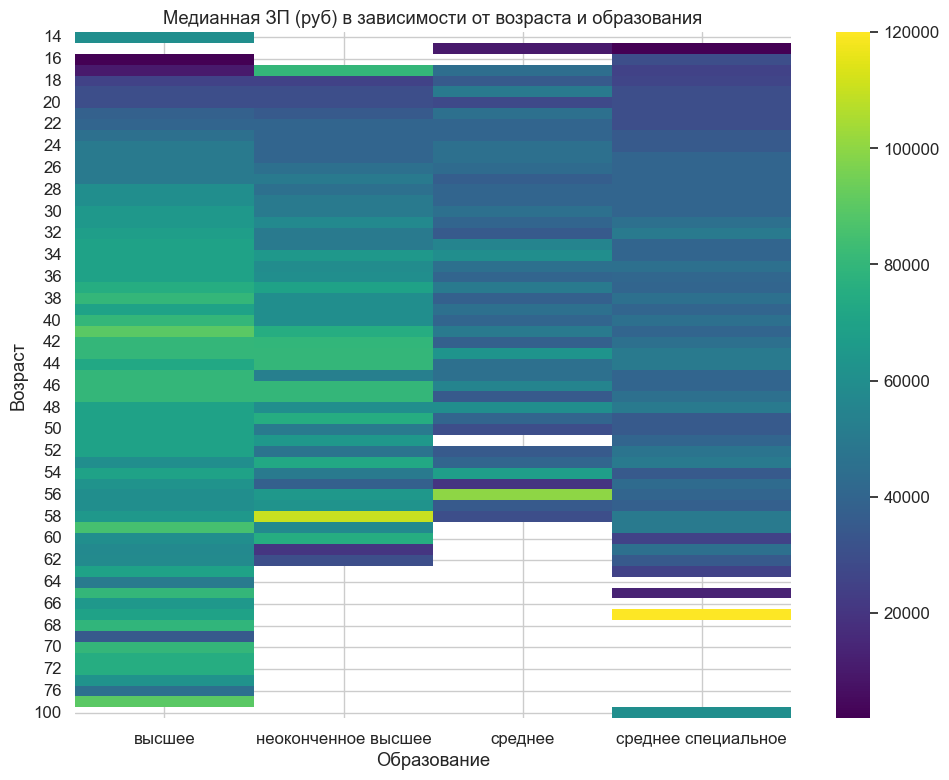

In [38]:
# ваш код здесь
# ограничим ЗП, чтобы не портили медиану экстремальные значения
data_heat = hh_salary_filtered.copy()

pivot = data_heat.pivot_table(
    index='Возраст',
    columns='Образование',
    values='ЗП (руб)',
    aggfunc='median'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap='viridis')
plt.title('Медианная ЗП (руб) в зависимости от возраста и образования')
plt.xlabel('Образование')
plt.ylabel('Возраст')
plt.tight_layout()
plt.show()


Выводы по тепловой карте (медианная ЗП vs возраст и образование)
1. Уровень образования сильно влияет на желаемую заработную плату
На тепловой карте видно, что:
Высшее образование → consistently более высокие медианные ЗП во всех возрастах.
Неоконченное высшее → показатели немного ниже, но тенденции схожи.
Среднее специальное → заметно ниже, но стабильнее распределено по возрастам.
Среднее образование → самая низкая медианная ЗП среди категорий.

Это подтверждает, что образование — сильный фактор при прогнозировании ЗП.

2. Возрастной тренд: медианная ЗП растёт до ~40–45 лет, затем снижается
Практически во всех уровнях образования видно:
ЗП увеличивается от 20 до ~40 лет (рост опыта + рост квалификации).
Пик медианных ЗП наблюдается примерно в возрастах 35–45.
После 50–55 лет медианная ЗП начинает снижаться.

Такой тренд характерен для рынка труда: высокие ожидания в зрелом возрасте и снижение в предпенсионный период.

3. Самые высокие медианные ЗП — у возрастной группы 35–45 лет с высшим образованием
Эта группа выделяется яркими (жёлто-зелёными) зонами.
Именно здесь работодатели чаще предлагают более квалифицированные должности.

4. Большой разброс внутри категорий, особенно у пожилых соискателей
В возрастах 60+ видно:
значительные скачки (яркие участки),
отсутствие данных в некоторых ячейках (белые зоны — мало резюме),
неустойчивые медианные значения.

Это означает, что:
группа малочисленна,
данные больше подвержены шуму,
уровень запросов сильно варьируется.

5. Низкие значения ЗП в молодом возрасте объясняются отсутствием опыта
Возраст 14–20 лет показывает:
самые низкие медианные значения,
почти не различается по уровню образования,
т.к. у большинства в эти годы нет опыта работы.

6. Среднее специальное образование демонстрирует стабильность
Хотя медианные ЗП ниже, тепловая карта показывает:
плавные изменения по возрасту,
меньше аномальных скачков,
наиболее равномерное распределение.

Это связано с тем, что большинство таких профессий имеют предсказуемый диапазон ЗП.

7. "Среднее" образование — самая низкооплачиваемая категория
Категория “среднее” стабильно остаётся самой низкооплачиваемой по медианной ЗП во всех возрастах.

Итоговые ключевые инсайты
Образование — один из сильнейших предикторов уровня зарплаты.
Пиковая медианная ЗП приходится на возраст 35–45 лет.
После 50–55 лет запросы заметно снижаются.
Высшее образование обеспечивает самый высокий “потолок” ЗП.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

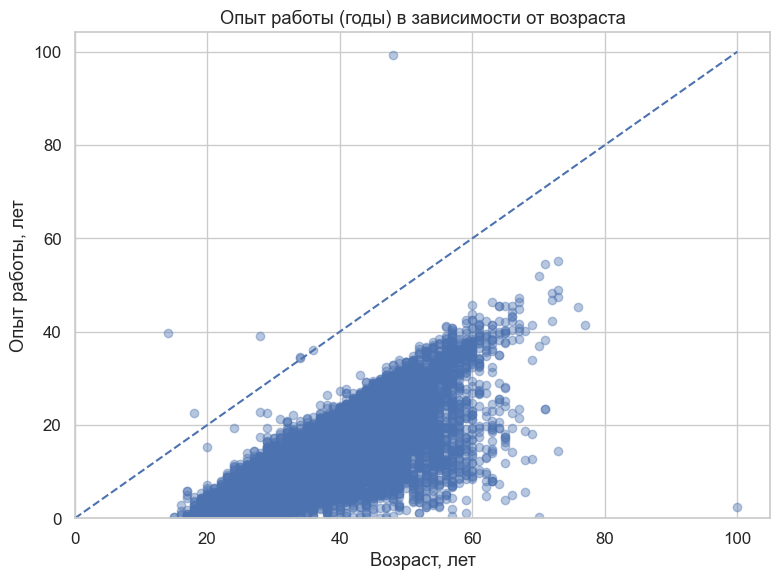

In [39]:
# ваш код здесь
plt.figure(figsize=(8, 6))

# опыт в годах
experience_years = hh['Опыт работы (месяц)'] / 12

plt.scatter(hh['Возраст'], experience_years, alpha=0.4)
plt.title('Опыт работы (годы) в зависимости от возраста')
plt.xlabel('Возраст, лет')
plt.ylabel('Опыт работы, лет')

# добавляем прямую (0,0)–(100,100)
plt.plot([0, 100], [0, 100], linestyle='--')

plt.xlim(0, hh['Возраст'].max() + 5)
plt.ylim(0, max(experience_years.dropna().max() + 5, 10))

plt.tight_layout()
plt.show()


Выводы по диаграмме рассеяния «Возраст — Опыт работы»
1. Большинство точек лежит ниже диагонали
Диагональная линия показывает идеальный максимум опыта = возрасту, что означает:
человек работал каждый год своей жизни (что в реальности невозможно).
Практически все соискатели находятся ниже этой линии, что подтверждает:
опыт работы всегда меньше возраста,
трудовая деятельность начинается не с рождения, а примерно с 18–22 лет.

Это говорит о корректности большинства наблюдений.

2. Выраженный треугольный контур распределения
Форма облака данных представляет собой треугольник, расширяющийся с возрастом:
молодые соискатели (20–25 лет) имеют опыт от 0 до 5 лет,
в 30–40 лет — разброс опыта заметно шире (5–20 лет),
к 50–60 годам часто встречается опыт 20–35 лет.
Это соответствует естественной логике карьерного пути.

3. Аномалии: опыт работы превышает возраст
На графике видны точки выше диагональной линии.
Это означает:
указанный опыт работы ≥ возрасту соискателя — невозможная ситуация.

Такие случаи свидетельствуют о:
неправильном вводе данных,
ошибках при заполнении резюме,
автоматическом парсинге, где объединены несколько мест работы.
Эти данные нужно удалить (ты это будешь делать дальше по заданию проекта).

4. Некоторые экстремальные выбросы
Видны точки:
опыт > 40 лет при возрасте 30–40 — невозможно;
опыт ~100 лет — очевидный выброс;
опыт 30–40 лет при возрасте < 40 — также ошибки.
Эти наблюдения искажают статистику и нуждаются в очистке.

5. Общая тенденция: умеренная положительная связь
Хотя разброс большой, заметно:
чем старше возраст, тем выше потенциальный опыт работы,
зависимость нелинейная: в молодости рост опыта быстрый, после 40 — замедляется.

6. Данные реалистичны для большинства соискателей
Основная масса наблюдений:
возраст 25–55,
опыт 3–25 лет,
никаких сильных провалов или нелогичных групп не наблюдается.

Это подтверждает, что набор данных качественный, а выбросы — редкие.

Итоговые ключевые инсайты

Большинство данных правдоподобны: опыт меньше возраста.
Аномалии чётко видны и подлежат удалению.
Наблюдается естественная связь возраста и опыта.
Диапазоны опыта логично расширяются с возрастом.
Распределение в целом реалистично и пригодно для анализа после удаления ошибок.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


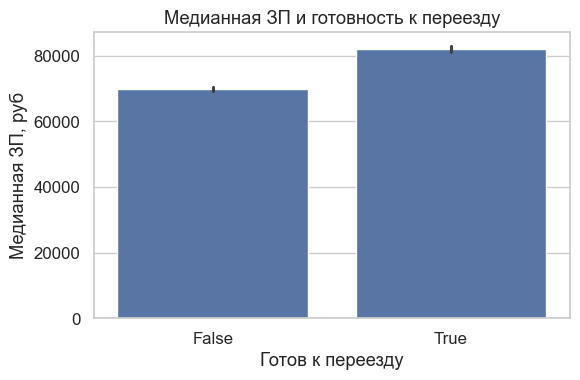

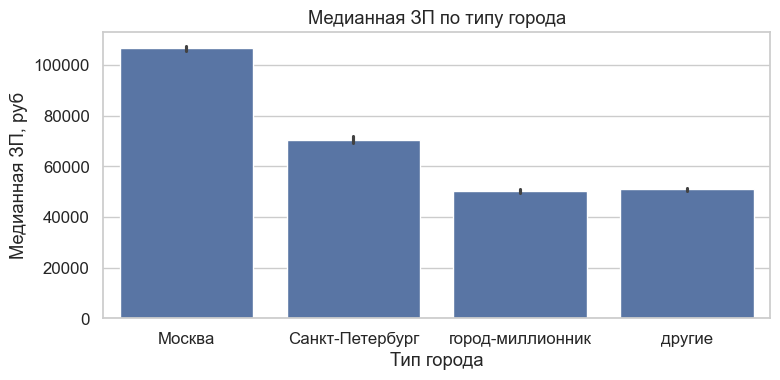

In [40]:
# ваш код здесь
# 1. Медианная ЗП в зависимости от готовности к переезду
plt.figure(figsize=(6, 4))
sns.barplot(
    data=hh_salary_filtered,
    x='Готовность к переезду',
    y='ЗП (руб)'
)
plt.title('Медианная ЗП и готовность к переезду')
plt.xlabel('Готов к переезду')
plt.ylabel('Медианная ЗП, руб')
plt.tight_layout()
plt.show()

# 2. Медианная ЗП по категориям города
plt.figure(figsize=(8, 4))
sns.barplot(
    data=hh_salary_filtered,
    x='Город',
    y='ЗП (руб)',
    order=['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие']
)
plt.title('Медианная ЗП по типу города')
plt.xlabel('Тип города')
plt.ylabel('Медианная ЗП, руб')
plt.tight_layout()
plt.show()


Выводы по графику: «Медианная ЗП и готовность к переезду»

1. Соискатели, готовые к переезду, ожидают заметно более высокую зарплату.
Медианная ЗП:

Не готовы к переезду: ~70 000 руб.

Готовы к переезду: ~82 000 руб.

Разница составляет примерно +12 000 руб. (+17%).

2. Готовность к переезду — индикатор более высоких запросов и амбиций.
Обычно именно специалисты с более высокой квалификацией готовы рассматривать переезд ради лучшего предложения.

3. Возможно, соискатели ориентируются на зарплаты в более крупных городах.
Часто те, кто готов к переезду, планируют именно переезд в Москву или Санкт-Петербург, где зарплаты выше.

Итог:
Готовность к переезду — значимый фактор, коррелирующий с уровнем ожидаемой ЗП.
Такие кандидаты рассчитывают на более высокие условия труда и могут претендовать на более высокие зарплаты.

Выводы по графику: «Медианная ЗП по типу города»

1. Москва существенно выделяется среди всех типов городов.
Медианная желаемая зарплата соискателей здесь самая высокая — около 105 000 руб.
Это ожидаемо, учитывая концентрацию вакансий, крупных компаний и высокие расходы на жизнь.

2. Санкт-Петербург занимает уверенное второе место.
Медианная ЗП — около 70 000 руб., что заметно ниже Москвы, но значительно выше других городов.

3. Города-миллионники имеют схожий уровень зарплат с остальными городами.
Медианная ЗП — около 50 000 руб., что указывает на большой разрыв между двумя столицами и всеми остальными регионами.

4. «Другие» города практически не отличаются от городов-миллионников.
Разница в медианной ЗП минимальна — около 50 000 руб.
Это говорит о том, что региональный рынок труда более однороден по уровню ожиданий.

Итог:
Тип города оказывает сильное влияние на уровень ожидаемой зарплаты.
Москва и в меньшей степени Санкт-Петербург формируют отдельные высокодоходные зоны.
Все остальные регионы находятся примерно на одном уровне.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [41]:
# ваш код здесь
# количество полных дубликатов
hh.duplicated().sum()

# удаляем дубликаты (если есть)
hh = hh.drop_duplicates().reset_index(drop=True)


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [42]:
# ваш код здесь
hh.isna().sum()


ЗП                                     0
Ищет работу на должность:              0
Опыт работы                          166
Последнее/нынешнее место работы        1
Последняя/нынешняя должность           2
Обновление резюме                      0
Авто                                   0
Образование                            0
Пол                                    0
Возраст                                0
Город                                  0
Готовность к переезду                  0
Готовность к командировкам             0
Занятость_полная занятость             0
Занятость_частичная занятость          0
Занятость_проектная работа             0
Занятость_волонтерство                 0
Занятость_стажировка                   0
График_полный день                     0
График_сменный график                  0
График_гибкий график                   0
График_удаленная работа                0
График_вахтовый метод                  0
Опыт работы (месяц)                  188
ЗП_число        

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [43]:

# ваш код здесь
# удаляем строки, где нет места работы или должности
hh = hh.dropna(
    subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность']
)

# заполняем пропуски в опыте работы медианой
median_exp = hh['Опыт работы (месяц)'].median()
hh['Опыт работы (месяц)'] = hh['Опыт работы (месяц)'].fillna(median_exp)


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [44]:
# ваш код здесь
hh = hh[(hh['ЗП (руб)'] <= 1_000_000) & (hh['ЗП (руб)'] >= 1_000)]


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [45]:
# ваш код здесь
experience_years = hh['Опыт работы (месяц)'] / 12

mask_bad = experience_years >= hh['Возраст']
# можно посмотреть, сколько таких записей:
# hh[mask_bad].shape

hh = hh[~mask_bad].reset_index(drop=True)


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

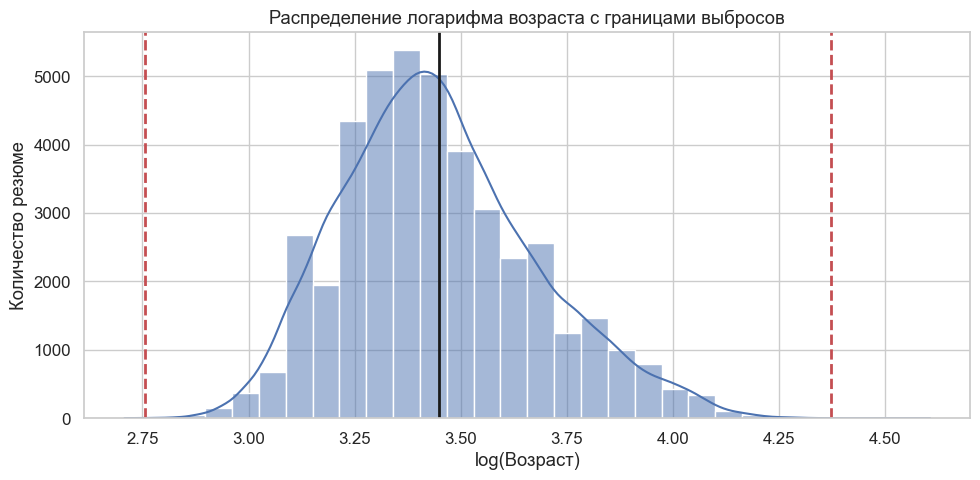

In [46]:
# ваш код здесь
# логарифм возраста
log_age = np.log(hh['Возраст'])

plt.figure(figsize=(10, 5))
histplot = sns.histplot(log_age, bins=30, kde=True)
mean_log = log_age.mean()
std_log = log_age.std()

# линии среднего и границ (3 сигмы слева, 4 сигмы справа)
histplot.axvline(mean_log, color='k', lw=2)
histplot.axvline(mean_log - 3*std_log, color='r', lw=2, linestyle='--')
histplot.axvline(mean_log + 4*std_log, color='r', lw=2, linestyle='--')

plt.title('Распределение логарифма возраста с границами выбросов')
plt.xlabel('log(Возраст)')
plt.ylabel('Количество резюме')
plt.tight_layout()
plt.show()

# считаем z-отклонения
z_age = (log_age - mean_log) / std_log

# границы: 3 сигмы слева, 4 сигмы справа
lower_bound = -3
upper_bound = 4

outliers_mask = (z_age < lower_bound) | (z_age > upper_bound)
age_outliers = hh[outliers_mask]

# выводим таблицу с выбросами
age_outliers[['Возраст']].describe()

# после анализа удаляем выбросы
hh = hh[~outliers_mask].reset_index(drop=True)


ваш коммментарий здесь